#### Se parte de la estructura del modelo de parallelization

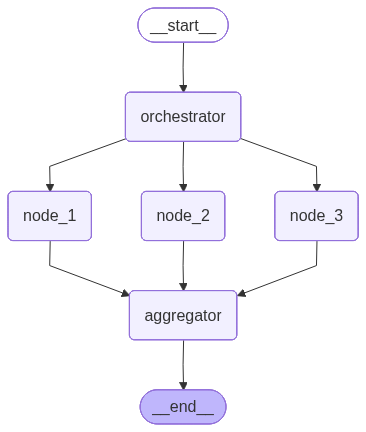

In [9]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from typing import Literal
from IPython.display import Image, display

class State(MessagesState):
    nodes: list[str]


def orchestrator(state: State):
    return state


def node_1(state: State):
    return state


def node_2(state: State):
    return state


def node_3(state: State):
    return state


def aggregator(state: State):
    return state


builder = StateGraph(State)

builder.add_node('orchestrator', orchestrator)
builder.add_node('node_1', node_1)
builder.add_node('node_2', node_2)
builder.add_node('node_3', node_3)
builder.add_node('aggregator', aggregator)

builder.add_edge(START, 'orchestrator')
builder.add_edge('orchestrator', 'node_1')
builder.add_edge('orchestrator', 'node_2')
builder.add_edge('orchestrator', 'node_3')
builder.add_edge('node_1', 'aggregator')
builder.add_edge('node_2', 'aggregator')
builder.add_edge('node_3', 'aggregator')
builder.add_edge('aggregator', END)
agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))


#### Esta es la lógica que se busca que haga el Orchestrator, pero no de forma aleatoria, sino basada en las necesidades del problema a resolver (un LLM más inteligente decidirá qué nodos necesita ejecutar para resolver el problema, y cuáles no).

In [10]:
import random
nodes = ["node_1", "node_2", "node_3"]
nodes = random.sample(nodes, random.randint(1, 3))
print(nodes)

['node_2']


#### Ahora se aplica esto para estructurar el Grafo tipo Orchestrator

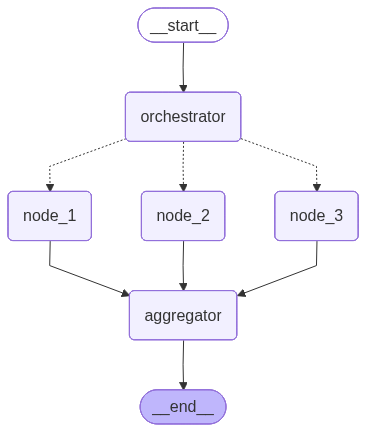

In [ ]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from typing import Literal
from IPython.display import Image, display
import random
from langgraph.types import Send # Esto sirve para enviar mensajes entre nodos, si es necesario

class State(MessagesState):
    nodes: list[str]


def orchestrator(state: State):
    nodes = ["node_1", "node_2", "node_3"]
    nodes = random.sample(nodes, random.randint(1, 3))
    return {"nodes": nodes}

def node_1(state: State):
    return state


def node_2(state: State):
    return state


def node_3(state: State):
    return state


def aggregator(state: State):
    return state

def assign_nodes(state: State) -> Literal["node_1", "node_2", "node_3"]:
    nodes = state['nodes']
    return [Send(node, {}) for node in nodes]


builder = StateGraph(State)

builder.add_node('orchestrator', orchestrator)
builder.add_node('node_1', node_1)
builder.add_node('node_2', node_2)
builder.add_node('node_3', node_3)
builder.add_node('aggregator', aggregator)

builder.add_edge(START, 'orchestrator')
builder.add_conditional_edges('orchestrator', assign_nodes)
builder.add_edge('node_1', 'aggregator')
builder.add_edge('node_2', 'aggregator')
builder.add_edge('node_3', 'aggregator')
builder.add_edge('aggregator', END)
agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))
